<a href="https://colab.research.google.com/github/GabriellaPompeu/Learning-Pytorch/blob/main/IntroToNeuralNetwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Performing the initial imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

##Creating the model class

In [2]:
# Create a model class that inherits nn.Module
class Model(nn.Module):
  # Input layer (4 features of the flower) -->
  # Hidden Layer1 (number of neurons) -->
  # Hidden Layer2 (number of neurons) -->
  # output (3 classes of flowers)

  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [3]:
# Pick a manual seed for randomization. Obs.: I like the number 37
torch.manual_seed(37)

# Create an instance of model
model = Model()

##Loading the data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [6]:
my_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [7]:
# Change the names of species to numbers
my_df['species'] = my_df['species'].replace('setosa', 0.0)
my_df['species'] = my_df['species'].replace('versicolor', 1.0)
my_df['species'] = my_df['species'].replace('virginica', 2.0)

my_df

/tmp/ipykernel_678/1221530390.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica', 2.0)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


##Training the model

In [8]:
# Train test split | Set X, Y
X = my_df.drop('species', axis=1)
y = my_df['species']

In [9]:
if isinstance(X, pd.DataFrame) or isinstance(X, pd.Series): # Check type before converting
    X = X.values # Convert to numpy arrays

if isinstance(y, pd.DataFrame) or isinstance(y, pd.Series): # Check type before converting
    y = y.values # Convert to numpy arrays

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)

In [12]:
# Convert X features to floar tensors and convert y labels to tensors long
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [13]:
# Set the criterion of model measure the error
criterion = nn.CrossEntropyLoss()

# Choose Adam Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [14]:
# Train our model
# Epoch = 1 run through all the training data in our network

epochs = 100
losses = []

for i in range(epochs):
  y_pred = model.forward(X_train) # Get predicted results
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())
  if i % 10 == 0: print(f'Epoch {i} and loss {loss}')
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch 0 and loss 1.1160037517547607
Epoch 10 and loss 0.9097009301185608
Epoch 20 and loss 0.6399168372154236
Epoch 30 and loss 0.39741843938827515
Epoch 40 and loss 0.24613669514656067
Epoch 50 and loss 0.1419191211462021
Epoch 60 and loss 0.09454261511564255
Epoch 70 and loss 0.07604443281888962
Epoch 80 and loss 0.06783639639616013
Epoch 90 and loss 0.06353626400232315


Text(0.5, 0, 'Epoch')

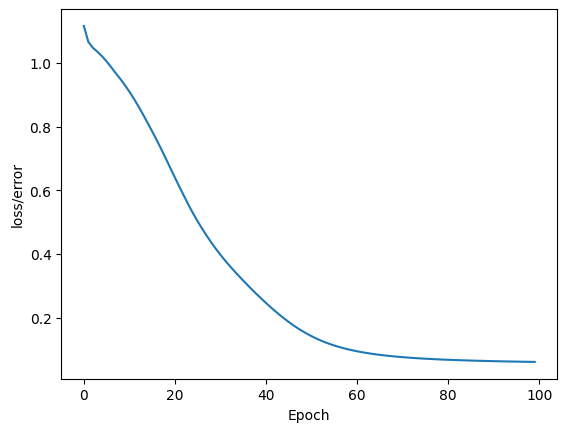

In [15]:
# Graph all this
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel("Epoch")

##Evaluating the test dataset

In [16]:
# validate model on test set

with torch.no_grad():
  y_eval = model.forward(X_test)
  loss = criterion(y_eval, y_test)


In [17]:
loss

tensor(0.0408)

In [18]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)

    if y_test[i] == 0:
      x = 'Setosa'
    elif y_test[i] == 1:
      x = 'Versicolor'
    else:
      x = 'Virginica'

    # Will tell us what type of flower de Network thinks it is
    print(f'{i+1}.) {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    # Checking if it's correct
    if y_val.argmax().item() == y_test[i]:
      correct += 1

  print(f'{correct} are correct')


1.) tensor([-4.0119,  3.7193,  0.0551]) 	 1 	 1
2.) tensor([ 14.0101,   7.2759, -19.5480]) 	 0 	 0
3.) tensor([ 13.2079,   7.3558, -18.8271]) 	 0 	 0
4.) tensor([-4.0333,  4.1824, -0.3694]) 	 1 	 1
5.) tensor([-8.3578,  1.6380,  5.5494]) 	 2 	 2
6.) tensor([-8.6295,  2.9537,  4.5207]) 	 2 	 2
7.) tensor([ 12.2674,   7.2407, -17.8373]) 	 0 	 0
8.) tensor([ 13.6045,   7.3289, -19.1786]) 	 0 	 0
9.) tensor([-3.5022,  4.3082, -0.9219]) 	 1 	 1
10.) tensor([ 14.2149,   7.6237, -20.0331]) 	 0 	 0
11.) tensor([-3.9658,  4.3905, -0.6107]) 	 1 	 1
12.) tensor([-9.0563,  1.2265,  6.4873]) 	 2 	 2
13.) tensor([-1.7704,  4.1252, -2.1411]) 	 1 	 1
14.) tensor([-1.4217,  5.2155, -3.4532]) 	 1 	 1
15.) tensor([-7.7943,  2.0055,  4.7348]) 	 2 	 2
16.) tensor([-9.2195,  0.4932,  7.3176]) 	 2 	 2
17.) tensor([-4.5126,  3.3856,  0.7712]) 	 1 	 1
18.) tensor([-6.8059,  2.3301,  3.6303]) 	 2 	 2
19.) tensor([-1.7623,  4.7361, -2.7257]) 	 1 	 1
20.) tensor([ 15.1148,   7.9800, -21.2173]) 	 0 	 0
21.) tensor

## Evaluating a new data on the network

In [19]:
new_iris = torch.tensor([4.7, 3.2, 1.3, 0.2])

In [21]:
with torch.no_grad():
  print(model(new_iris))

tensor([ 13.4292,   7.1492, -18.8622])


##Saving our NN Model


In [22]:
torch.save(model.state_dict(), 'my_iris_model.pt')

##Loading our saved model

In [23]:
new_model = Model()
new_model.load_state_dict(torch.load('my_iris_model.pt'))

<All keys matched successfully>

In [24]:
new_model.eval()

Model(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=9, bias=True)
  (out): Linear(in_features=9, out_features=3, bias=True)
)